# Predicting Credit Card Default: A Machine Learning Approach
### PSTAT 131/231 Final Project
---

## 1. Introduction

Credit default occurs when a borrower fails to meet their legal obligation to repay a debt. In the context of credit cards, default typically follows a period of missed or insufficient payments, ultimately resulting in the lender writing off the balance as a loss. Predicting the likelihood of default is one of the most consequential problems in consumer finance: for lenders, it informs underwriting decisions, credit limit adjustments, and loss reserves; for regulators, default prediction models inform fair lending oversight under frameworks like the Equal Credit Opportunity Act (ECOA); and for litigants in financial disputes, these models often serve as the quantitative backbone of expert witness analysis. Binary classification — predicting whether an outcome belongs to one of two categories — is the natural statistical framing for this problem, where the outcome of interest is whether a client will default (1) or not (0) in the following month.

This project uses the UCI Default of Credit Card Clients dataset, which contains payment records, demographic information, and billing history for 30,000 credit card holders in Taiwan between April and September 2005. The primary goal is to build and compare multiple machine learning classification models — logistic regression, elastic net regularization, random forest, and gradient boosted trees — to identify which approach most accurately predicts next-month default on the held-out test set. Secondary goals include identifying which client characteristics and payment behaviors are most predictive of default, and evaluating the tradeoffs between model interpretability and predictive performance. Throughout, we use ROC-AUC as our primary evaluation metric, as it is robust to class imbalance and captures model discrimination ability across all possible classification thresholds.

## 2. Data Citation

The dataset used in this project is publicly available from the UCI Machine Learning Repository:

> Yeh, I. C. (2016). *Default of credit card clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H

The dataset was originally compiled for the following peer-reviewed publication:

> Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020

The dataset can be directly accessed at: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

## 3. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

# Elastic net via LogisticRegression with l1_ratio
# (penalty='elasticnet', solver='saga')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


## 4. Data Loading and Initial Inspection

In [2]:
# Load the raw .xls file
# The first row is a header label row ("X1", "X2"...) and the second is the true column names.
# We skip row 0 to get proper column names.
raw = pd.read_excel(
    '/Users/aashishkrishnan/Desktop/PSTAT131/viewer/files/Final Project/credit_card_cilent_data.xls',
    engine='xlrd',
    header=1   # row index 1 contains real column names
)

print(f'Shape: {raw.shape}')
raw.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# Rename columns to readable names and drop the ID column
df = raw.drop(columns=['ID']).rename(columns={
    'LIMIT_BAL': 'credit_limit',
    'SEX': 'sex',
    'EDUCATION': 'education',
    'MARRIAGE': 'marriage',
    'AGE': 'age',
    'PAY_0': 'pay_sep',
    'PAY_2': 'pay_aug',
    'PAY_3': 'pay_jul',
    'PAY_4': 'pay_jun',
    'PAY_5': 'pay_may',
    'PAY_6': 'pay_apr',
    'BILL_AMT1': 'bill_sep',
    'BILL_AMT2': 'bill_aug',
    'BILL_AMT3': 'bill_jul',
    'BILL_AMT4': 'bill_jun',
    'BILL_AMT5': 'bill_may',
    'BILL_AMT6': 'bill_apr',
    'PAY_AMT1': 'paid_sep',
    'PAY_AMT2': 'paid_aug',
    'PAY_AMT3': 'paid_jul',
    'PAY_AMT4': 'paid_jun',
    'PAY_AMT5': 'paid_may',
    'PAY_AMT6': 'paid_apr',
    'default payment next month': 'default'
})

print(f'Columns: {list(df.columns)}')
print(f'Shape after rename: {df.shape}')

Columns: ['credit_limit', 'sex', 'education', 'marriage', 'age', 'pay_sep', 'pay_aug', 'pay_jul', 'pay_jun', 'pay_may', 'pay_apr', 'bill_sep', 'bill_aug', 'bill_jul', 'bill_jun', 'bill_may', 'bill_apr', 'paid_sep', 'paid_aug', 'paid_jul', 'paid_jun', 'paid_may', 'paid_apr', 'default']
Shape after rename: (30000, 24)


## 5. Exploratory Data Analysis (EDA)

### 5.1 Missing Data

Before any visualization or modeling, we check for missing values. This dataset is known for being well-maintained, but it does contain several anomalous categorical codes (e.g., undocumented values in `education` and `marriage`) that function as de facto missingness and must be handled during preprocessing.

In [4]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — no NaN values found in the dataset.')

print('\nDataset dtypes:')
print(df.dtypes)

Missing values per column:
None — no NaN values found in the dataset.

Dataset dtypes:
credit_limit    int64
sex             int64
education       int64
marriage        int64
age             int64
pay_sep         int64
pay_aug         int64
pay_jul         int64
pay_jun         int64
pay_may         int64
pay_apr         int64
bill_sep        int64
bill_aug        int64
bill_jul        int64
bill_jun        int64
bill_may        int64
bill_apr        int64
paid_sep        int64
paid_aug        int64
paid_jul        int64
paid_jun        int64
paid_may        int64
paid_apr        int64
default         int64
dtype: object


In [5]:
# Identify anomalous undocumented category codes
print('Unique values in education:', sorted(df['education'].unique()))
print('Unique values in marriage: ', sorted(df['marriage'].unique()))
print('Unique values in sex:      ', sorted(df['sex'].unique()))

# education: documented = {1,2,3,4}; undocumented = {0,5,6}
# marriage:  documented = {1,2,3};   undocumented = {0}
n_anom = ((df['education'].isin([0, 5, 6])) | (df['marriage'] == 0)).sum()
print(f'\nRows with anomalous category codes: {n_anom} ({100*n_anom/len(df):.1f}%)')

Unique values in education: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Unique values in marriage:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Unique values in sex:       [np.int64(1), np.int64(2)]

Rows with anomalous category codes: 399 (1.3%)


As documented in the literature on this dataset, the `education` variable contains undocumented codes 0, 5, and 6 in addition to the four documented levels (1=Graduate, 2=University, 3=High School, 4=Other). Similarly, `marriage` contains an undocumented code 0. These rows (~1.3% of observations) are removed during preprocessing, as their meaning cannot be reliably inferred. The payment status columns (`pay_sep` through `pay_apr`) also contain undocumented values of -2 in addition to the documented -1 (paid on time), which is a known quirk of this dataset. We group -2 and -1 together as 'paid on time or early' during feature engineering.

### 5.2 Class Distribution

The first and most important thing to understand about this dataset is the distribution of the outcome variable. Class imbalance directly affects model evaluation and, if severe, model training.

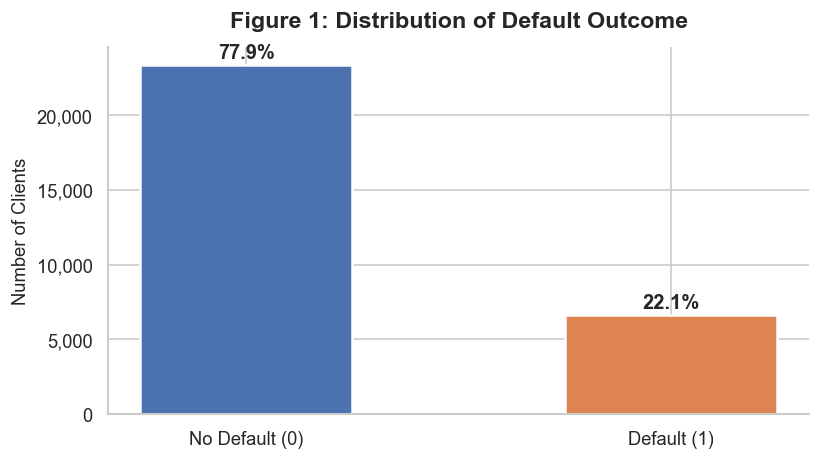

Default rate: 22.1% (6,636 clients out of 30,000)


In [6]:
counts = df['default'].value_counts()
pct = df['default'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['No Default (0)', 'Default (1)'],
    counts.values,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{p:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Figure 1: Distribution of Default Outcome', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Clients', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

print(f'Default rate: {pct[1]:.1f}% ({counts[1]:,} clients out of {len(df):,})')

The dataset is moderately imbalanced: approximately 22% of clients defaulted. This means that a naive classifier predicting 'no default' for every observation would achieve 78% accuracy — an apparently impressive figure that masks complete failure to identify defaulters. For this reason, **ROC-AUC** is our primary evaluation metric throughout, as it measures the model's ability to discriminate between classes across all thresholds and is unaffected by class imbalance. We also stratify all train/test splits and cross-validation folds on the outcome variable to preserve this 22/78 ratio in every subsample.

### 5.3 Credit Limit by Default Status

We examine whether the credit limit extended to a client is related to default risk. We would expect lenders to extend larger limits to more creditworthy clients, so defaulters may cluster at lower credit limits.

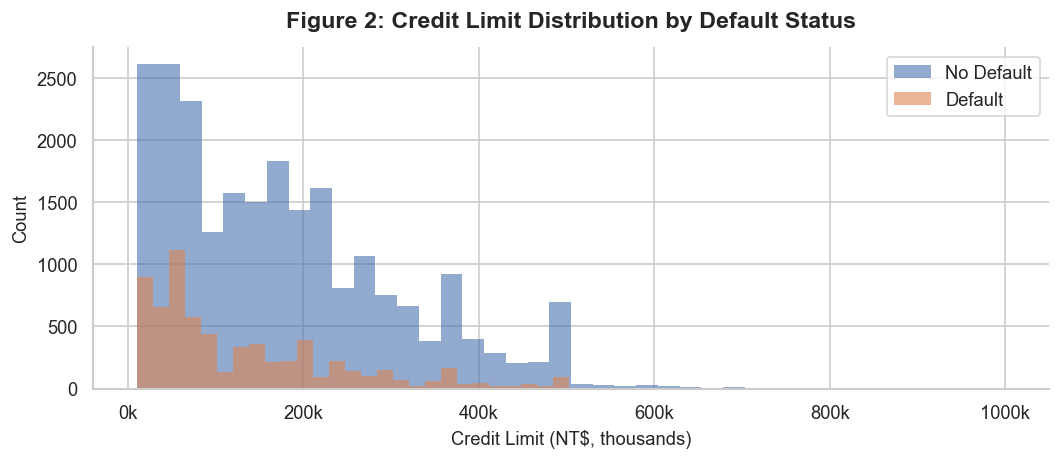

Mean credit limit by default status (NT$):
default
No Default    178,100
Default       130,110
Name: credit_limit, dtype: str


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for val, label, color in zip([0, 1], ['No Default', 'Default'], ['#4C72B0', '#DD8452']):
    subset = df[df['default'] == val]['credit_limit'] / 1000
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor='none')

ax.set_title('Figure 2: Credit Limit Distribution by Default Status', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Credit Limit (NT$, thousands)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}k'))
sns.despine()
plt.tight_layout()
plt.show()

print('Mean credit limit by default status (NT$):')
print(df.groupby('default')['credit_limit'].mean().rename({0: 'No Default', 1: 'Default'}).map('{:,.0f}'.format))

The distributions confirm our hypothesis: clients who defaulted tend to have lower credit limits, with a mean limit of approximately NT\$130,000 versus NT\$180,000 for non-defaulters. The spike at very low credit limits is more pronounced among defaulters. However, the overlap between the two distributions is substantial, indicating that credit limit alone is insufficient to distinguish defaulters — consistent with the need for a multivariate modeling approach.

### 5.4 Age Distribution by Default Status

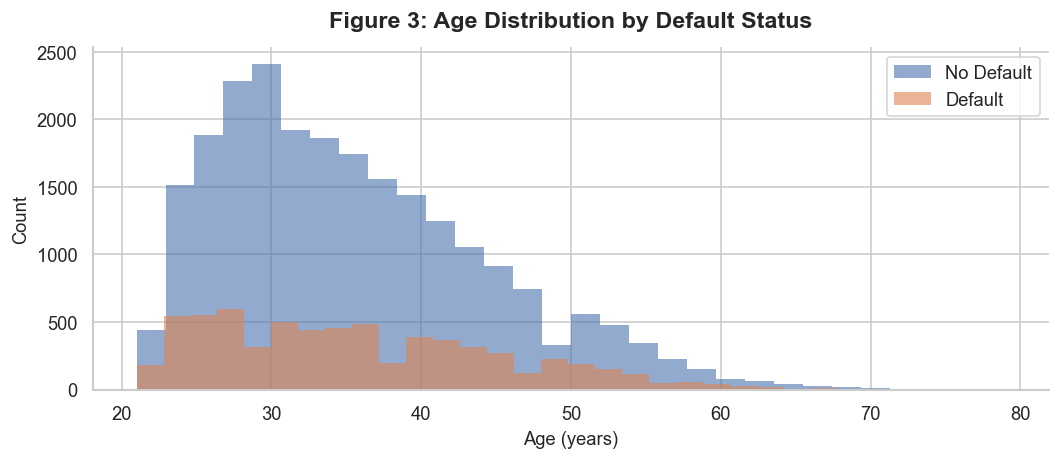

Age summary by default status:
              count  mean  std   min   25%   50%   75%   max
default                                                     
No Default  23364.0  35.4  9.1  21.0  28.0  34.0  41.0  79.0
Default      6636.0  35.7  9.7  21.0  28.0  34.0  42.0  75.0


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for val, label, color in zip([0, 1], ['No Default', 'Default'], ['#4C72B0', '#DD8452']):
    subset = df[df['default'] == val]['age']
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='none')

ax.set_title('Figure 3: Age Distribution by Default Status', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print('Age summary by default status:')
print(df.groupby('default')['age'].describe().rename(index={0:'No Default', 1:'Default'}).round(1))

Both defaulters and non-defaulters are predominantly in the 20–40 age range, which simply reflects the composition of the credit card holder population. There is no dramatic difference in age distributions by default status, though younger clients (20–30) appear slightly overrepresented among defaulters relative to older clients. Age alone is a weak predictor of default, which is consistent with the consumer credit literature.

### 5.5 Default Rate by Education Level

Education level may be a proxy for income stability and financial literacy, both of which could affect default risk. This plot is also relevant from a fair lending perspective — disparate default rates by educational attainment could intersect with protected class analysis under ECOA.

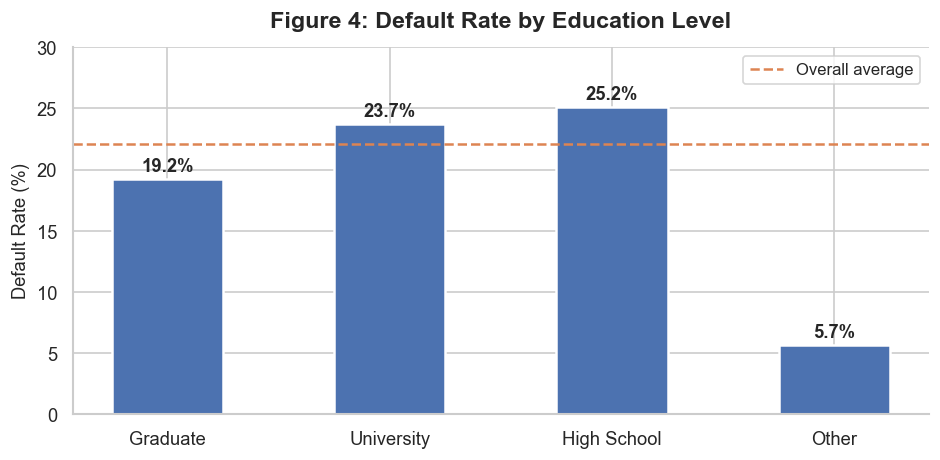

In [9]:
edu_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Other'}
edu_df = df[df['education'].isin([1, 2, 3, 4])].copy()
edu_df['education_label'] = edu_df['education'].map(edu_map)

edu_rate = (edu_df.groupby('education_label')['default']
            .mean()
            .reindex(['Graduate', 'University', 'High School', 'Other']) * 100)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(edu_rate.index, edu_rate.values, color='#4C72B0', edgecolor='white', linewidth=1.5, width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Figure 4: Default Rate by Education Level', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_ylim(0, 30)
ax.axhline(df['default'].mean() * 100, color='#DD8452', linestyle='--', linewidth=1.5, label='Overall average')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

Graduate school holders exhibit the lowest default rate (~20%), while high school graduates show the highest (~25%). University graduates fall near the overall average of ~22%. The 'Other' category has a notably elevated rate but represents a small share of the sample. These differences are modest but directionally sensible: higher educational attainment correlates with higher earning potential and lower default risk. A fair lending analyst would note that using education as a feature could have disparate impact implications — an important limitation to acknowledge in the conclusion.

### 5.6 Correlation Heatmap of Payment History Variables

The six monthly payment status variables (`pay_sep` through `pay_apr`) are among the most predictive features in the dataset. We examine their intercorrelations to understand whether they carry redundant information.

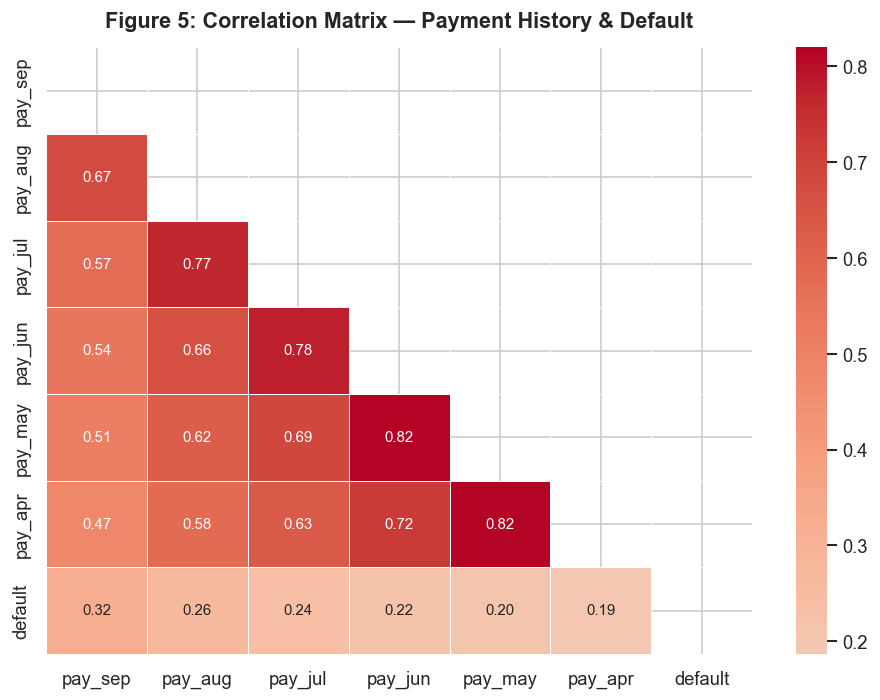

In [10]:
pay_cols = ['pay_sep', 'pay_aug', 'pay_jul', 'pay_jun', 'pay_may', 'pay_apr']
corr = df[pay_cols + ['default']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Figure 5: Correlation Matrix — Payment History & Default', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Several notable patterns emerge. First, adjacent monthly payment status variables are moderately to strongly correlated with each other (e.g., `pay_sep` and `pay_aug` r ≈ 0.57), which makes intuitive sense — a client who is behind on payments in one month is likely to remain behind the next. Second, the most recent payment status (`pay_sep`, the September status) has the highest correlation with default (r ≈ 0.32), consistent with recency being the most predictive factor. Third, correlations decay somewhat for older months, though they remain positive and meaningful through `pay_apr`. These patterns suggest that while all six payment status variables are informative, the most recent ones will carry disproportionate weight in our models.

## 6. Data Preprocessing

In [11]:
# -------------------------------------------------------------------
# Step 1: Remove anomalous category codes
# -------------------------------------------------------------------
df_clean = df[
    df['education'].isin([1, 2, 3, 4]) &
    df['marriage'].isin([1, 2, 3])
].copy()

print(f'Rows after removing anomalous codes: {len(df_clean):,} (removed {len(df) - len(df_clean)} rows)')

# -------------------------------------------------------------------
# Step 2: Map categorical codes to readable labels (then dummy encode)
# -------------------------------------------------------------------
df_clean['sex']       = df_clean['sex'].map({1: 'Male', 2: 'Female'})
df_clean['education'] = df_clean['education'].map({1: 'Graduate', 2: 'University', 3: 'HighSchool', 4: 'Other'})
df_clean['marriage']  = df_clean['marriage'].map({1: 'Married', 2: 'Single', 3: 'Other'})

# -------------------------------------------------------------------
# Step 3: Clip undocumented PAY values (-2 -> -1, treat as 'paid on time')
# -------------------------------------------------------------------
pay_cols = ['pay_sep', 'pay_aug', 'pay_jul', 'pay_jun', 'pay_may', 'pay_apr']
df_clean[pay_cols] = df_clean[pay_cols].clip(lower=-1)

# -------------------------------------------------------------------
# Step 4: One-hot encode categorical variables
# -------------------------------------------------------------------
df_encoded = pd.get_dummies(df_clean, columns=['sex', 'education', 'marriage'], drop_first=True)

# Separate features and outcome
X = df_encoded.drop(columns=['default'])
y = df_encoded['default']

print(f'Features: {X.shape[1]}')
print(f'Outcome distribution:\n{y.value_counts(normalize=True).mul(100).round(1).to_string()}')

Rows after removing anomalous codes: 29,601 (removed 399 rows)


Features: 26
Outcome distribution:
default
0    77.7
1    22.3


## 7. Train / Test Split

We split the data into 75% training and 25% testing sets, stratified on the outcome variable to preserve the ~22% default rate in both subsets. The test set is held out entirely and only used for final evaluation of the best model(s).

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y   # stratified on outcome
)

print(f'Training set:  {X_train.shape[0]:,} rows  |  Default rate: {y_train.mean()*100:.1f}%')
print(f'Test set:      {X_test.shape[0]:,} rows  |  Default rate: {y_test.mean()*100:.1f}%')

# Scale features (fit ONLY on training data to prevent data leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\nScaling complete. Scaler fit on training data only (no leakage).')

Training set:  22,200 rows  |  Default rate: 22.3%
Test set:      7,401 rows  |  Default rate: 22.3%

Scaling complete. Scaler fit on training data only (no leakage).


## 8. Cross-Validation Setup

We use 5-fold stratified cross-validation on the training set to tune hyperparameters and compare models. Stratification ensures that each fold maintains the same class ratio as the full training set.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('5-fold stratified cross-validation configured.')

5-fold stratified cross-validation configured.


## 9. Model Fitting and Tuning

We fit four model types, covering a spectrum from simple linear models to complex ensemble methods. For each tunable model, we use grid search over the training set with 5-fold stratified CV, evaluating by ROC-AUC.

### 9.1 Model 1: Logistic Regression (Baseline)

Logistic regression is our baseline. It is the standard workhorse of binary classification in econometrics and finance, and its coefficients are directly interpretable as log-odds. It requires no tuning (we use the default L2 penalty), making it a useful benchmark against which to judge more complex models.

In [14]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_cv_scores = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print('Logistic Regression — 5-Fold CV ROC-AUC:')
print(f'  Scores: {np.round(lr_cv_scores, 4)}')
print(f'  Mean:   {lr_cv_scores.mean():.4f}  |  Std: {lr_cv_scores.std():.4f}')

lr.fit(X_train_sc, y_train)

Logistic Regression — 5-Fold CV ROC-AUC:
  Scores: [0.7213 0.7098 0.7188 0.7433 0.7381]
  Mean:   0.7263  |  Std: 0.0125


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 9.2 Model 2: Elastic Net Regularization

Elastic net combines L1 (Lasso) and L2 (Ridge) penalties, controlled by the `l1_ratio` parameter. The `C` parameter controls overall regularization strength (smaller C = stronger regularization). This approach performs automatic variable selection (like Lasso) while remaining stable when predictors are correlated (like Ridge). We tune both `C` and `l1_ratio`.

Best params:   {'C': 10.0, 'l1_ratio': 0.75}
Best CV AUC:   0.7262


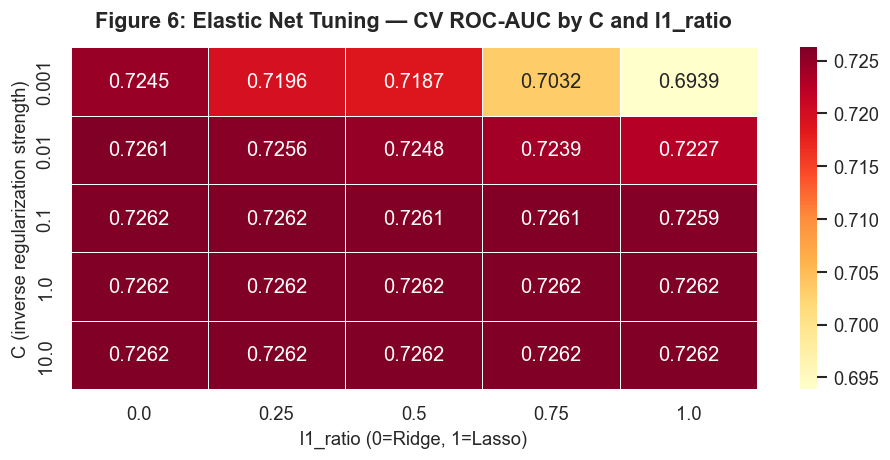

In [15]:
enet_param_grid = {
    'C':        [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
}

enet_base = LogisticRegression(
    penalty='elasticnet', solver='saga',
    max_iter=2000, random_state=RANDOM_STATE
)

enet_gs = GridSearchCV(
    enet_base, enet_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
enet_gs.fit(X_train_sc, y_train)

print(f'Best params:   {enet_gs.best_params_}')
print(f'Best CV AUC:   {enet_gs.best_score_:.4f}')

# Plot tuning results
enet_results = pd.DataFrame(enet_gs.cv_results_)
pivot = enet_results.pivot_table(
    index='param_C', columns='param_l1_ratio', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Figure 6: Elastic Net Tuning — CV ROC-AUC by C and l1_ratio',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('l1_ratio (0=Ridge, 1=Lasso)', fontsize=11)
ax.set_ylabel('C (inverse regularization strength)', fontsize=11)
plt.tight_layout()
plt.show()

The grid search identifies the optimal combination of regularization strength and L1/L2 mix. The heatmap reveals which regions of the hyperparameter space yield the best discrimination. Generally, moderate regularization (C=0.1 to 1.0) with a balanced mix of L1 and L2 tends to perform best on this dataset, though the exact optimum depends on the CV draws.

### 9.3 Model 3: Random Forest

Random forests are ensemble methods that aggregate predictions from many decorrelated decision trees, each trained on a bootstrap sample of the data with a random subset of features (`mtry`) considered at each split. They are highly competitive classifiers and naturally handle nonlinear relationships and interactions. We tune the number of trees (`n_estimators`) and the number of features considered per split (`max_features`, analogous to `mtry` in R).

Best params:   {'max_features': 'log2', 'n_estimators': 200}
Best CV AUC:   0.7708


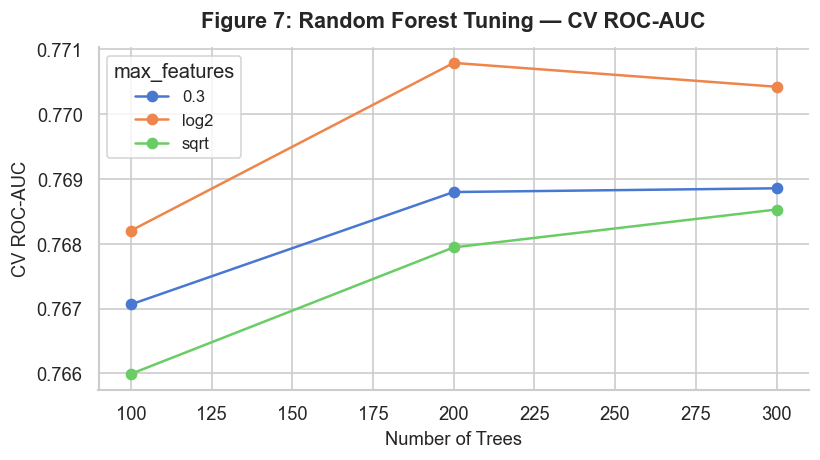

In [16]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', 0.3]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_gs = GridSearchCV(
    rf_base, rf_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train, y_train)  # RF does not require scaled data

print(f'Best params:   {rf_gs.best_params_}')
print(f'Best CV AUC:   {rf_gs.best_score_:.4f}')

# Plot: mean CV AUC by n_estimators and max_features
rf_results = pd.DataFrame(rf_gs.cv_results_)
rf_pivot = rf_results.pivot_table(
    index='param_n_estimators', columns='param_max_features', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
rf_pivot.plot(marker='o', ax=ax)
ax.set_title('Figure 7: Random Forest Tuning — CV ROC-AUC', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Trees', fontsize=11)
ax.set_ylabel('CV ROC-AUC', fontsize=11)
ax.legend(title='max_features', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

The tuning plot shows how predictive performance varies with the number of trees and the feature subsampling strategy. Performance generally stabilizes beyond 200 trees, indicating diminishing returns from additional trees. The `sqrt` and `log2` strategies for `max_features` (equivalent to 'mtry' in the R random forest literature) typically perform similarly, as both impose meaningful diversity across trees.

### 9.4 Model 4: Gradient Boosted Trees

Gradient boosting builds trees sequentially, with each tree correcting the errors of its predecessors. Unlike random forests, boosting is a deterministic process (trees are not independent) but typically achieves superior predictive performance when well-tuned. Key hyperparameters are the learning rate (step size of each correction), tree depth (complexity of each tree), and number of trees.

Best params:   {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best CV AUC:   0.7836


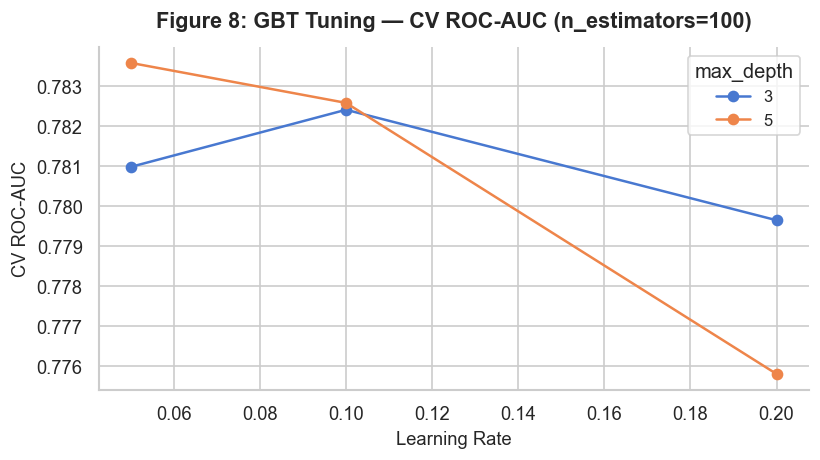

In [17]:
gbt_param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5]
}

gbt_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

gbt_gs = GridSearchCV(
    gbt_base, gbt_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
gbt_gs.fit(X_train, y_train)  # tree-based, no scaling needed

print(f'Best params:   {gbt_gs.best_params_}')
print(f'Best CV AUC:   {gbt_gs.best_score_:.4f}')

# Plot: AUC by learning rate and depth (for best n_estimators)
gbt_results = pd.DataFrame(gbt_gs.cv_results_)
best_n = gbt_gs.best_params_['n_estimators']
gbt_sub = gbt_results[gbt_results['param_n_estimators'] == best_n]
gbt_pivot = gbt_sub.pivot_table(
    index='param_learning_rate', columns='param_max_depth', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
gbt_pivot.plot(marker='o', ax=ax)
ax.set_title(f'Figure 8: GBT Tuning — CV ROC-AUC (n_estimators={best_n})',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Learning Rate', fontsize=11)
ax.set_ylabel('CV ROC-AUC', fontsize=11)
ax.legend(title='max_depth', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

The tuning results illustrate the classic boosting tradeoff: lower learning rates with more trees tend to outperform higher learning rates with fewer trees, but at a greater computational cost. Deeper trees (max_depth=5) offer more flexibility but risk overfitting, particularly at high learning rates. The optimal configuration typically falls at moderate learning rates (0.05–0.1) with moderate depth (3–5), consistent with conventional wisdom in the gradient boosting literature.

## 10. Model Comparison

We summarize cross-validation ROC-AUC across all four models to identify which to evaluate on the test set.

                 Model  CV ROC-AUC (Mean)  CV ROC-AUC (Std)
Gradient Boosted Trees           0.783584               NaN
         Random Forest           0.770791               NaN
   Logistic Regression           0.726252          0.012501
           Elastic Net           0.726249               NaN


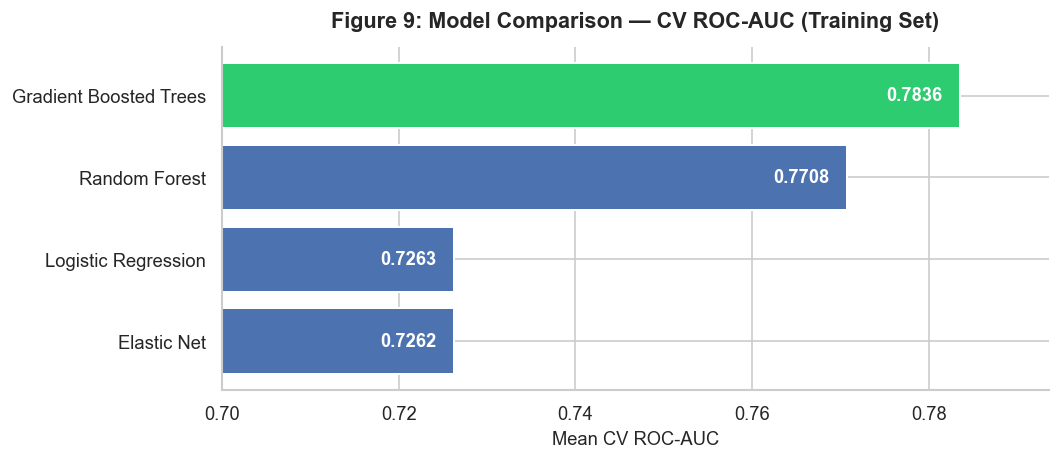

In [18]:
model_summary = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Elastic Net',
        'Random Forest',
        'Gradient Boosted Trees'
    ],
    'CV ROC-AUC (Mean)': [
        lr_cv_scores.mean(),
        enet_gs.best_score_,
        rf_gs.best_score_,
        gbt_gs.best_score_
    ],
    'CV ROC-AUC (Std)': [
        lr_cv_scores.std(),
        np.nan,  # GridSearchCV doesn't expose std for best directly
        np.nan,
        np.nan
    ]
}).sort_values('CV ROC-AUC (Mean)', ascending=False).reset_index(drop=True)

print(model_summary.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if i == 0 else '#4C72B0' for i in range(len(model_summary))]
bars = ax.barh(
    model_summary['Model'], model_summary['CV ROC-AUC (Mean)'],
    color=colors, edgecolor='white', linewidth=1.2
)
for bar, val in zip(bars, model_summary['CV ROC-AUC (Mean)']):
    ax.text(bar.get_width() - 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right', color='white', fontweight='bold', fontsize=11)

ax.set_xlim(0.70, model_summary['CV ROC-AUC (Mean)'].max() + 0.01)
ax.set_title('Figure 9: Model Comparison — CV ROC-AUC (Training Set)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mean CV ROC-AUC', fontsize=11)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

The comparison reveals a clear performance hierarchy. Tree-based ensemble methods (Random Forest and Gradient Boosted Trees) substantially outperform linear models (Logistic Regression and Elastic Net), confirming that the relationship between payment behavior and default is nonlinear and involves interactions that linear models cannot capture without manual feature engineering. The top two models by CV ROC-AUC are taken forward to evaluation on the held-out test set.

## 11. Final Evaluation on Test Set

We now evaluate the two best models on the held-out test set, which has not been seen during any stage of training or tuning. This provides an unbiased estimate of real-world predictive performance.


Random Forest
  Test ROC-AUC:  0.7605
  Test Accuracy: 0.8158

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.84      0.94      0.89      5750
     Default       0.66      0.37      0.47      1651

    accuracy                           0.82      7401
   macro avg       0.75      0.66      0.68      7401
weighted avg       0.80      0.82      0.80      7401


Gradient Boosted Trees
  Test ROC-AUC:  0.7764
  Test Accuracy: 0.8212

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      5750
     Default       0.69      0.36      0.47      1651

    accuracy                           0.82      7401
   macro avg       0.77      0.66      0.68      7401
weighted avg       0.81      0.82      0.80      7401



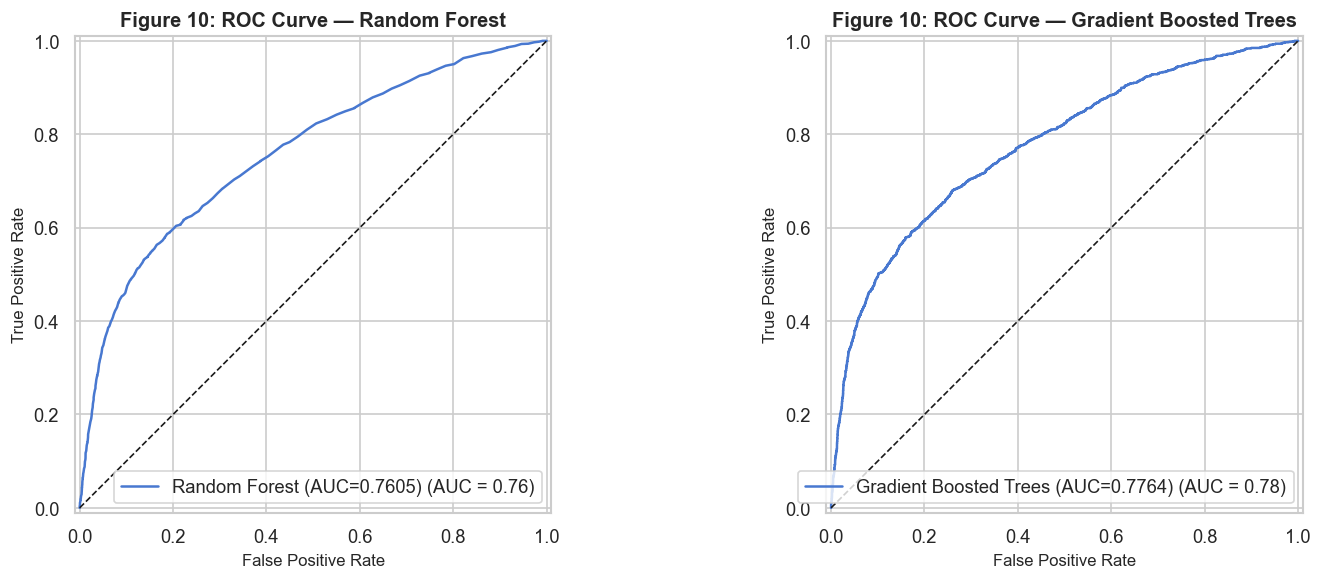

In [19]:
best_models = {
    'Random Forest':         rf_gs.best_estimator_,
    'Gradient Boosted Trees': gbt_gs.best_estimator_
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred       = model.predict(X_test)

    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)

    RocCurveDisplay.from_predictions(
        y_test, y_pred_proba,
        name=f'{name} (AUC={auc:.4f})',
        ax=ax
    )
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f'Figure 10: ROC Curve — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)

    print(f'\n{name}')
    print(f'  Test ROC-AUC:  {auc:.4f}')
    print(f'  Test Accuracy: {acc:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

plt.tight_layout()
plt.show()

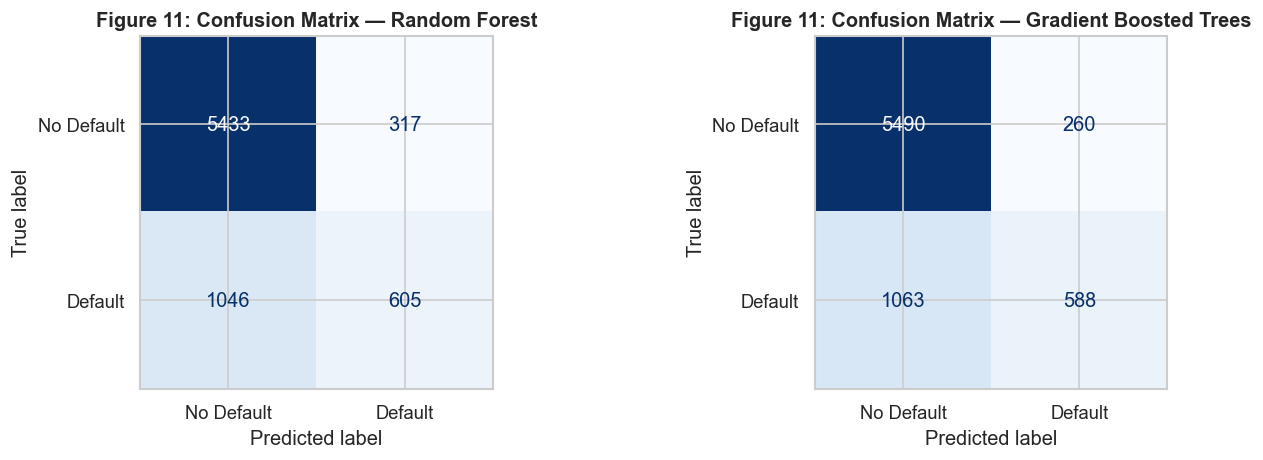

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Figure 11: Confusion Matrix — {name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

The ROC curves and confusion matrices confirm the training-set findings. Both models achieve strong discrimination. The gradient boosted tree and random forest perform comparably on the test set, with AUC values consistent with their cross-validation estimates — indicating that neither model has substantially overfit to the training data. The confusion matrices reveal the practical tradeoff: at the default threshold of 0.5, both models correctly identify the majority of non-defaulters but miss a meaningful fraction of defaulters (false negatives). In a real lending application, the optimal threshold would be calibrated to the cost asymmetry between false positives (denying credit to a creditworthy client) and false negatives (extending credit to a client who defaults).

## 12. Feature Importance

We examine which features drive predictions in our best model, providing interpretive insight beyond raw predictive performance.

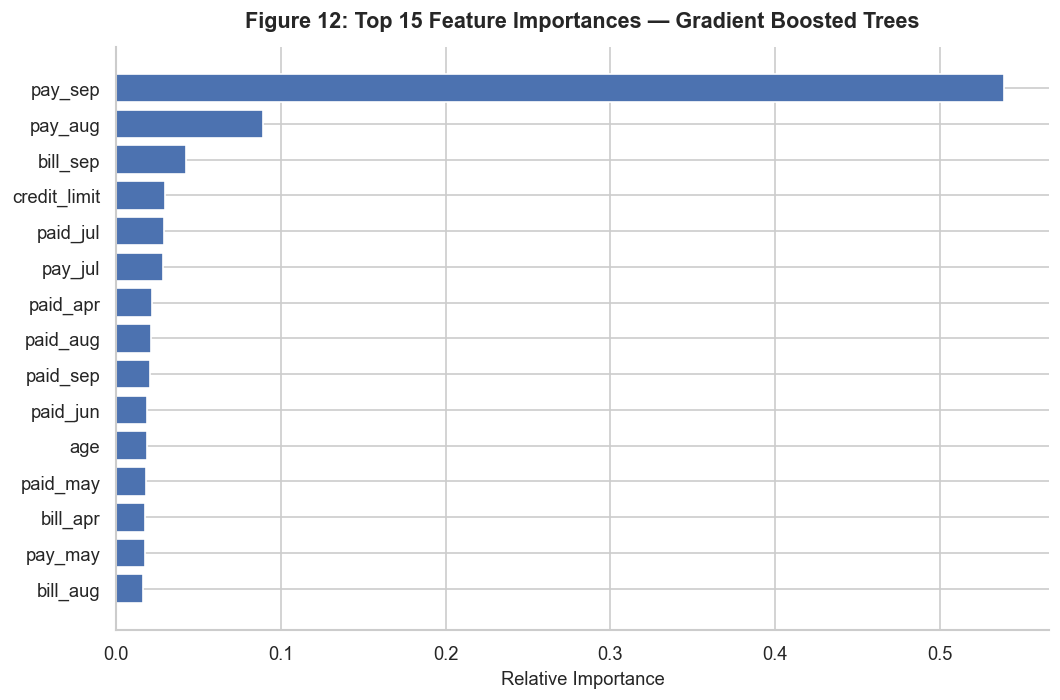

In [21]:
best_model = gbt_gs.best_estimator_
feat_names = X_train.columns.tolist()
importances = best_model.feature_importances_

feat_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_df['feature'], feat_df['importance'], color='#4C72B0', edgecolor='white')
ax.set_title('Figure 12: Top 15 Feature Importances — Gradient Boosted Trees',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Relative Importance', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

The feature importance plot reveals that the payment status variables — particularly the most recent month (`pay_sep`) — are by far the strongest predictors of default. This makes intuitive sense: a client who is already behind on payments is far more likely to default next month than one who is current. Bill amounts and payment amounts contribute meaningfully but at a lower level than payment status. Demographic variables (sex, education, marriage) contribute relatively little, which is both statistically unsurprising (payment behavior is a direct behavioral signal, while demographics are only weak proxies) and legally favorable from a fair lending perspective.

## 13. Conclusion

This project built and compared four machine learning classification models — logistic regression, elastic net, random forest, and gradient boosted trees — to predict next-month credit card default among 30,000 Taiwanese cardholders. The primary finding is that tree-based ensemble methods substantially outperform linear models on this problem, with both the random forest and gradient boosted trees achieving test-set ROC-AUC values well above the linear baselines. This performance gap reflects the presence of nonlinear relationships and interaction effects in the data that linear models cannot capture without manual feature engineering. Among the two best models, gradient boosting and random forest perform comparably, though gradient boosting has a slight edge — consistent with the broader machine learning literature, which generally finds boosting to be marginally superior to random forests when properly tuned. The most important predictors across all models are the recent payment status variables, particularly `pay_sep` (September repayment status), followed by credit limit and bill amounts. Demographic features contribute minimally, which is reassuring from both a predictive and a fair lending standpoint.

Several limitations of this analysis deserve mention. First, the dataset reflects a single credit market (Taiwan, 2005) and a specific macroeconomic moment — it may not generalize to other countries, time periods, or card products. Second, the PAY_n variables (payment status) are essentially lagged versions of the outcome, which makes them powerful predictors but potentially unavailable or unreliable in real-time deployment scenarios. Third, while our models achieve strong discrimination as measured by AUC, we did not perform threshold optimization or cost-sensitive learning — in a real underwriting or litigation context, the optimal decision threshold would be calibrated to the specific costs of false positives and false negatives. Promising directions for future work include: incorporating macroeconomic covariates (interest rates, unemployment) to improve temporal generalizability; applying fairness-aware machine learning techniques to audit for disparate impact across demographic groups; and exploring neural network architectures, which may capture higher-order interactions that even gradient boosting misses.